In [17]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, ConcatDataset
from torch.utils.data import random_split

In [10]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using device: CUDA")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"Using device: MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print(f"Using device: CPU")

Using device: CPU


In [8]:
!gsutil cp gs://quickdraw_dataset/full/numpy_bitmap/violin.npy .



Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://quickdraw_dataset/full/numpy_bitmap/violin.npy...
==> NOTE: You are downloading one or more large file(s), which would
run significantly faster if you enabled sliced object downloads. This
feature is enabled by default but requires that compiled crcmod be
installed (see "gsutil help crcmod").

/ [1 files][162.4 MiB/162.4 MiB]                                                
Operation completed over 1 objects/162.4 MiB.                                    
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs:

In [32]:
!gsutil cp gs://quickdraw_dataset/full/numpy_bitmap/guitar.npy .
!gsutil cp gs://quickdraw_dataset/full/numpy_bitmap/violin.npy .
!gsutil cp gs://quickdraw_dataset/full/numpy_bitmap/zebra.npy .
!gsutil cp gs://quickdraw_dataset/full/numpy_bitmap/trumpet.npy .
!gsutil cp gs://quickdraw_dataset/full/numpy_bitmap/hamburger.npy .

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://quickdraw_dataset/full/numpy_bitmap/guitar.npy...
\ [1 files][ 90.1 MiB/ 90.1 MiB]                                                
Operation completed over 1 objects/90.1 MiB.                                     
Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.
Copying gs://quickdraw_dataset/full/numpy_bitmap/violin.npy...
==> NOTE: You are downloading one or more large file(s), which would
run significantly faster if you enabled sliced object downloads. This
feature is enabled by default but requires that compil

In [34]:
# Transform that converts images to tensors and normalizes them for NN usage
mytransform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Class definitions - Turns dataset into class so that extracted features later
# on go through __getitem__ and get processed via the transform and reshaping
class quickdraw_dataset(Dataset):
  def __init__(self, file, label=0, transform=None):
    self.data = np.load(file)[:8000]
    self.transform = transform
    self.label = label

  def __len__(self):
    return len(self.data)

  def __getitem__(self, index):
    data = self.data[index]
    img = data.reshape(28, 28).astype(np.uint8)
    if self.transform:
      img = self.transform(img)
    return img, self.label

# List of dataset class objects that are equivalent to the categories I chose
dataset_list = []
# Arbitrary categories I chose for conversion into class objects so
# transformations are performed on them automatically when called via getitem
categories = ['violin', 'zebra', 'trumpet', 'hamburger']

# Converting data files to dataset class
for i, category in enumerate(categories):
  filepath = f'{category}.npy'
  ds = quickdraw_dataset(filepath, label=i, transform=mytransform)
  dataset_list.append(ds)

# Concatenating classes into ConcatDataset object so it functions as list
unified_dataset = ConcatDataset(dataset_list)

# Defining sizes for training and validation data
train_size = int(0.8*len(unified_dataset))
val_size = len(unified_dataset) - train_size

# Defining training and validation data
train_subset, val_subset = random_split(unified_dataset, [train_size, val_size])

# Dataloader object definitions
train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)

val_loader = DataLoader(val_subset, batch_size = 32, shuffle=False)


In [29]:
# Model definition
quickdraw_model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 4)
)

In [30]:
# Defining the training epoch (Not sure if this is standard practice but i don't care lol)
def training_epoch(model, loss_function, optimizer, dataloader, device):

  model = model.to(device)
  model.train()

  total_batches = len(dataloader)
  for batch_idx, (inputs, targets) in enumerate(dataloader):
    inputs, targets = inputs.to(device), targets.to(device)

    optimizer.zero_grad()
    outputs = model(inputs)
    loss = loss_function(outputs, targets)
    loss.backward()
    optimizer.step() # Corrected: Added parentheses to call the step method
  return model

# Defining evaluation (same as before)
def evaluate(model, test_loader, device):
  model.eval()
  correct = 0
  total = 0
  for inputs, targets in test_loader:
    inputs, targets = inputs.to(device), targets.to(device)
    outputs = model(inputs)

    _, predicted_indices = outputs.max(1)
    batch_size = targets.size(0)
    total += batch_size
    correct += (predicted_indices == targets).sum().item()
  accuracy = correct / total
  return accuracy

In [35]:
# Training Loop
epochs = 10
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(quickdraw_model.parameters(), lr=0.001)
accuracy_list = []
for epoch in range(epochs):
  quickdraw_model = training_epoch(quickdraw_model, loss_function, optimizer, train_loader, device)
  accuracy = evaluate(quickdraw_model, val_loader, device)
  accuracy_list.append(accuracy)
  print(accuracy)
print(accuracy_list)


0.90640625
0.91703125
0.91921875
0.9190625
0.9153125
0.91953125
0.9159375
0.92234375
0.9196875
0.913125
[0.90640625, 0.91703125, 0.91921875, 0.9190625, 0.9153125, 0.91953125, 0.9159375, 0.92234375, 0.9196875, 0.913125]


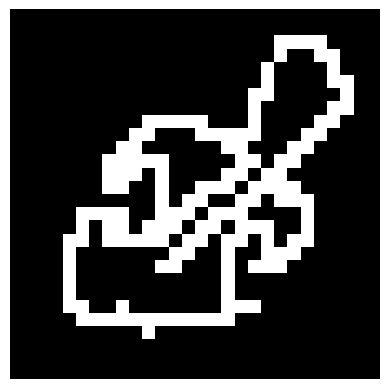

In [57]:
# pretty good results!
# i'll try it on a picture of a violin i drew
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread('violin.png')
plt.imshow(img)
plt.axis('off')
plt.show()

In [59]:
from PIL import Image

# Let's turn the violin image into a tensor of the shape that the neural network was trained on
img = Image.open('violin.png')
violin_npy = np.array(img)
violin_npy = violin_npy.flatten()
violin_npy = torch.from_numpy(violin_npy)
violin_npy = violin_npy.reshape(1,784)
violin_npy.shape
violin_npy = violin_npy.float() / 255.0
violin_npy = (violin_npy - 0.5) / 0.5

# Now let's see what the prediction is
model_output = quickdraw_model(violin_npy)
print(model_output)

tensor([[ 1.9147, -2.6623,  0.4476, -2.3500]], grad_fn=<AddmmBackward0>)


In [60]:
# Values are nonsensical because we need to apply softmax that was applied in loss function
import torch.nn.functional as F
probabilities = F.softmax(model_output, dim=1)
print(probabilities)

tensor([[0.7968, 0.0082, 0.1838, 0.0112]], grad_fn=<SoftmaxBackward0>)


In [ ]:
# index 0 is violin, so the model succeeded!